# 🔬 Embryo Morphokinetic Stage Classification 

**Models:** MobileNetV2 · InceptionV3 · VGG16 


---
## 📦 Section 0 — Environment Setup

In [1]:
import os, sys, warnings
# Silence ALL C-level JPEG warnings before TF loads
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
warnings.filterwarnings('ignore')

import tensorflow as tf
tf.get_logger().setLevel('ERROR')

import subprocess
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                       'scikit-learn', 'matplotlib', 'seaborn', 'tqdm'])
print("✅ Dependencies ready")


E0000 00:00:1775569418.723012      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775569418.784131      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775569419.223235      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775569419.223293      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775569419.223296      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775569419.223298      55 computation_placer.cc:177] computation placer already registered. Please check linka

✅ Dependencies ready


In [2]:
import os, re, csv, json, random, tarfile, hashlib, gc, io
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.auto import tqdm   # auto selects notebook vs terminal bar

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, backend as K
from tensorflow.keras.applications import MobileNetV2, InceptionV3, VGG16, VGG19
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau,
    CSVLogger, Callback, LambdaCallback
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print(f'GPUs: {len(gpus)}')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
    print(f'  {gpu}')
if not gpus:
    print('  ⚠️  No GPU — training will be very slow')

# Mixed precision — speeds up T4 by ~2x
keras.mixed_precision.set_global_policy('mixed_float16')
print('Mixed precision: ON (float16)')


TensorFlow: 2.19.0
GPUs: 1
  PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
Mixed precision: ON (float16)


---
## 📁 Section 1 — Configuration

In [3]:
BASE_DIR    = Path('/kaggle/working')
CKPT_DIR    = BASE_DIR / 'checkpoints'
LOG_DIR     = BASE_DIR / 'logs'
RESULTS_DIR = BASE_DIR / 'results'
CACHE_DIR   = BASE_DIR / 'cache'

for d in [CKPT_DIR, LOG_DIR, RESULTS_DIR, CACHE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

KAGGLE_INPUT = Path('/kaggle/input')

# Auto-locate dataset
print('=== Scanning /kaggle/input/ ===')
for item in KAGGLE_INPUT.iterdir():
    print(f'  {item}')

IMAGES_DIR = next((c for c in KAGGLE_INPUT.rglob('embryo_dataset')
                   if c.is_dir() and any(c.iterdir())), None)
ANNOTS_DIR = next((c for c in KAGGLE_INPUT.rglob('embryo_dataset_annotations')
                   if c.is_dir()), None)

# Handle nested folder case (dataset inside dataset folder)
if IMAGES_DIR is not None:
    sub = IMAGES_DIR / 'embryo_dataset'
    if sub.exists() and sub.is_dir():
        IMAGES_DIR = sub

if IMAGES_DIR is None or ANNOTS_DIR is None:
    # Fallback: extract from tar.gz in /kaggle/input
    DATA_DIR = BASE_DIR / 'embryo_data'
    DATA_DIR.mkdir(exist_ok=True)
    img_tar = next(KAGGLE_INPUT.rglob('embryo_dataset.tar.gz'), None)
    ann_tar = next(KAGGLE_INPUT.rglob('embryo_dataset_annotations.tar.gz'), None)

    def _extract(tar_path, dest, marker):
        m = dest / marker
        if m.exists(): print(f'  Already extracted: {marker}'); return m
        dest.mkdir(exist_ok=True)
        print(f'  Extracting {tar_path.name} ...')
        with tarfile.open(tar_path, 'r:gz') as tar:
            for member in tqdm(tar.getmembers(), desc='Extracting', mininterval=2):
                tar.extract(member, path=dest, set_attrs=False)
        return m

    if img_tar: IMAGES_DIR = _extract(img_tar, DATA_DIR, 'embryo_dataset')
    if ann_tar: ANNOTS_DIR = _extract(ann_tar, DATA_DIR, 'embryo_dataset_annotations')

assert IMAGES_DIR and ANNOTS_DIR, '❌ Dataset not found. Add it via +Add Data on Kaggle.'
print(f'\n✅ Images : {IMAGES_DIR}')
print(f'✅ Annots : {ANNOTS_DIR}')

# 16 morphokinetic phase labels
PHASE_LABELS = [
    'pPB2','pPNa','pPNf',
    'p2','p3','p4','p5','p6','p7','p8','p9+',
    'pM','pSB','pB','pEB','pHB'
]
NUM_CLASSES = len(PHASE_LABELS)
# Accept both t-prefix (CSV format) and p-prefix
LABEL2IDX = {}
for i, pl in enumerate(PHASE_LABELS):
    LABEL2IDX[pl] = i
    LABEL2IDX[pl.replace('p','t',1)] = i  # tPB2 → 0, t2 → 3, etc.
IDX2LABEL = {i: PHASE_LABELS[i] for i in range(NUM_CLASSES)}

# Hyperparameters
IMG_SIZE_MOBILE    = (224, 224)
IMG_SIZE_INCEPTION = (299, 299)
IMG_SIZE_VGG       = (224, 224)
BATCH_SIZE    = 32
EPOCHS_HEAD   = 10   # Phase 1: frozen base
EPOCHS_TUNE   = 25   # Phase 2: fine-tune
LEARNING_RATE = 3e-4
FINE_LR       = 1e-5
VAL_SPLIT     = 0.15
TEST_SPLIT    = 0.15

print(f'\nClasses ({NUM_CLASSES}): {PHASE_LABELS}')


=== Scanning /kaggle/input/ ===
  /kaggle/input/datasets

✅ Images : /kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset/embryo_dataset
✅ Annots : /kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset_annotations

Classes (16): ['pPB2', 'pPNa', 'pPNf', 'p2', 'p3', 'p4', 'p5', 'p6', 'p7', 'p8', 'p9+', 'pM', 'pSB', 'pB', 'pEB', 'pHB']


---
## 🗂️ Section 2 — JPEG Validation + Dataset Build
> **Key fix:** Pre-scan all files for JPEG corruption so no bad file ever enters the training pipeline.

In [4]:
def is_valid_jpeg(path: Path) -> bool:
    """
    Fast JPEG validity check — reads only the last 2 bytes (EOI marker FF D9).
    A truncated JPEG is missing this marker. This is the root cause of
    'Premature end of JPEG file' errors.
    """
    try:
        with open(path, 'rb') as f:
            f.seek(-2, 2)           # seek to 2 bytes before end
            return f.read(2) == b'\xff\xd9'
    except Exception:
        return False


def parse_annotations(annots_dir: Path) -> dict:
    """Parse all CSV annotation files. Handles space and comma delimiters."""
    ann_map = {}
    csv_files = sorted(annots_dir.glob('**/*.csv')) or sorted(annots_dir.glob('*.csv'))
    print(f'Found {len(csv_files)} annotation CSVs.')
    for csv_path in csv_files:
        video_id = csv_path.stem.replace('_phases', '')
        phases = []
        with open(csv_path, 'r', newline='') as f:
            for line in f.read().strip().splitlines():
                parts = line.split() if ',' not in line else line.split(',')
                if len(parts) < 3: continue
                try:
                    phases.append((parts[0].strip(), int(parts[1]), int(parts[2])))
                except ValueError:
                    continue
        phases.sort(key=lambda x: x[1])
        ann_map[video_id] = phases
    return ann_map


def frame_to_label(frame_idx: int, phases: list):
    current = None
    for label, start, end in phases:
        if frame_idx >= start: current = label
        else: break
    return current


VALID_CACHE = CACHE_DIR / 'valid_files.csv'

def build_dataset_df(images_dir: Path, annots_dir: Path,
                     use_cache: bool = True) -> pd.DataFrame:
    if use_cache and VALID_CACHE.exists():
        print(f'Loading cached dataset from {VALID_CACHE}')
        return pd.read_csv(VALID_CACHE)

    ann_map = parse_annotations(annots_dir)
    video_dirs = sorted(d for d in images_dir.iterdir() if d.is_dir())
    print(f'Found {len(video_dirs)} video folders.')

    records = []
    bad_jpegs = 0
    skipped_videos = 0

    for video_dir in tqdm(video_dirs, desc='Scanning & validating frames'):
        vid = video_dir.name
        if vid not in ann_map or not ann_map[vid]:
            skipped_videos += 1
            continue
        phases = ann_map[vid]

        # Try .jpeg first (actual extension in dataset), then .jpg
        img_files = sorted(video_dir.glob('*.jpeg'))
        if not img_files:
            img_files = sorted(video_dir.glob('*.jpg'))

        for img_path in img_files:
            # ── KEY FIX: skip corrupt JPEGs BEFORE they enter tf.data ─────────
            if not is_valid_jpeg(img_path):
                bad_jpegs += 1
                continue

            digits = re.findall(r'\d+', img_path.stem)
            frame_idx = int(digits[-1]) if digits else 0
            raw_label = frame_to_label(frame_idx, phases)
            if raw_label is None or raw_label not in LABEL2IDX:
                continue

            label_idx = LABEL2IDX[raw_label]
            records.append({
                'filepath'  : str(img_path),
                'label'     : IDX2LABEL[label_idx],
                'label_idx' : label_idx,
                'video_id'  : vid,
                'frame_idx' : frame_idx,
            })

    df = pd.DataFrame(records)
    df.to_csv(VALID_CACHE, index=False)

    print(f'Skipped videos (no annotation): {skipped_videos}')
    print(f'Corrupt/truncated JPEGs removed: {bad_jpegs:,}')
    print(f'Total valid labeled frames: {len(df):,}')
    print('\nClass distribution:')
    print(df['label'].value_counts().reindex(PHASE_LABELS))
    return df


master_df = build_dataset_df(IMAGES_DIR, ANNOTS_DIR)
master_df.to_csv(BASE_DIR / 'master_dataset.csv', index=False)
print('\n✅ master_dataset.csv saved')


Found 704 annotation CSVs.
Found 704 video folders.


Scanning & validating frames:   0%|          | 0/704 [00:00<?, ?it/s]

Skipped videos (no annotation): 0
Corrupt/truncated JPEGs removed: 27,659
Total valid labeled frames: 306,296

Class distribution:
label
pPB2     8253
pPNa    39652
pPNf     6333
p2      27134
p3       4530
p4      27246
p5       7080
p6       7799
p7      10119
p8      31834
p9+     53283
pM      19965
pSB     19156
pB      10426
pEB     33389
pHB        97
Name: count, dtype: int64

✅ master_dataset.csv saved


---
## 📊 Section 3 — Exploratory Data Analysis

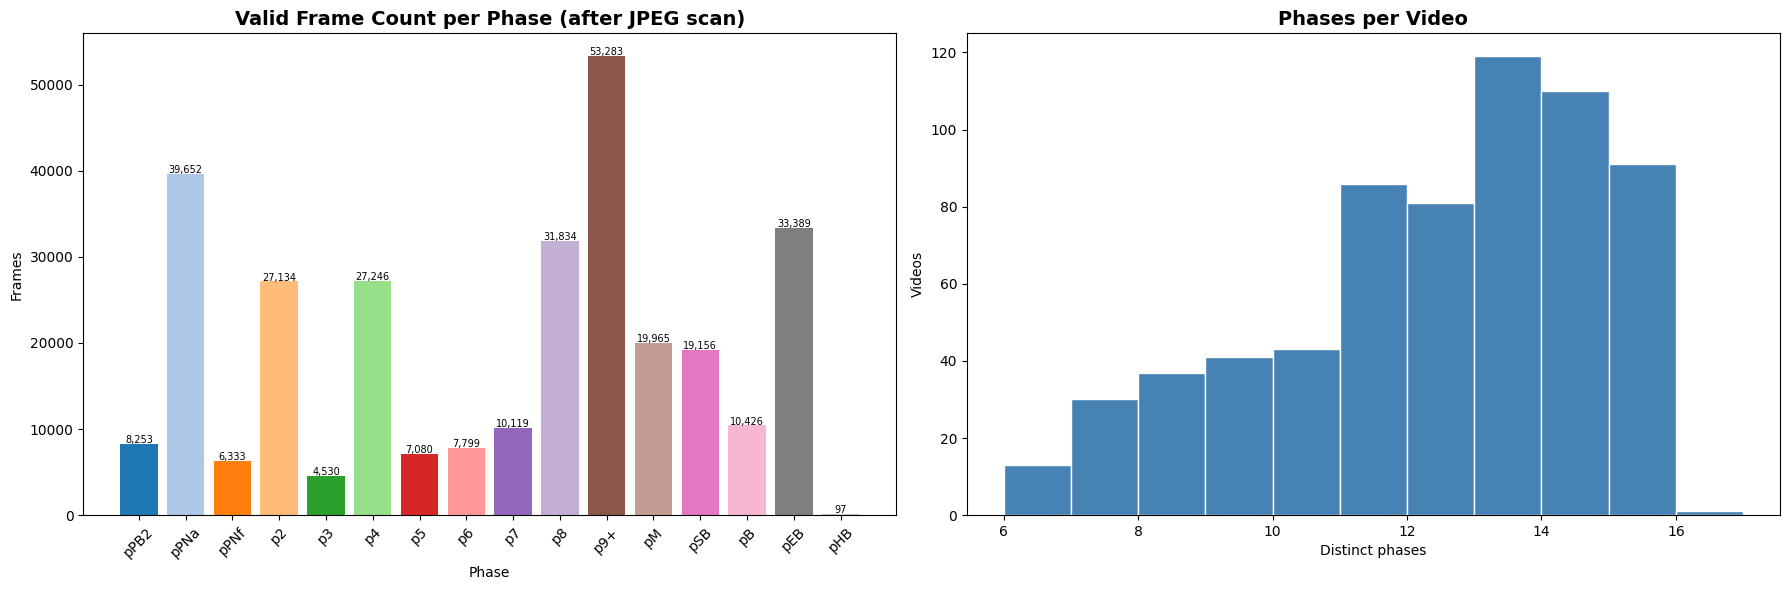

Total videos : 652
Total frames : 306,296
Imbalance    : 549.3x  (max=p9+:53283, min=pHB:97)


In [5]:
counts = master_df['label'].value_counts().reindex(PHASE_LABELS).fillna(0).astype(int)
phases_per_video = master_df.groupby('video_id')['label'].nunique()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
colors = plt.cm.tab20.colors[:NUM_CLASSES]

bars = axes[0].bar(PHASE_LABELS, counts.values, color=colors)
axes[0].set_title('Valid Frame Count per Phase (after JPEG scan)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Phase'); axes[0].set_ylabel('Frames')
axes[0].tick_params(axis='x', rotation=45)
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v+100, f'{v:,}', ha='center', fontsize=7)

axes[1].hist(phases_per_video.values, bins=range(6,18), color='steelblue', edgecolor='white')
axes[1].set_title('Phases per Video', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Distinct phases'); axes[1].set_ylabel('Videos')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda.png', dpi=150, bbox_inches='tight')
plt.show()

min_c, max_c = counts[counts>0].min(), counts.max()
print(f'Total videos : {master_df["video_id"].nunique()}')
print(f'Total frames : {len(master_df):,}')
print(f'Imbalance    : {max_c/max(min_c,1):.1f}x  (max={counts.idxmax()}:{max_c}, min={counts[counts>0].idxmin()}:{min_c})')


---
## ✂️ Section 4 — Video-level Train/Val/Test Split

In [6]:
rng = np.random.default_rng(SEED)
video_ids = rng.permutation(master_df['video_id'].unique())
n = len(video_ids)
n_test  = int(n * TEST_SPLIT)
n_val   = int(n * VAL_SPLIT)

train_vids = set(video_ids[:n - n_test - n_val])
val_vids   = set(video_ids[n - n_test - n_val : n - n_test])
test_vids  = set(video_ids[n - n_test:])

train_df = master_df[master_df['video_id'].isin(train_vids)].reset_index(drop=True)
val_df   = master_df[master_df['video_id'].isin(val_vids)].reset_index(drop=True)
test_df  = master_df[master_df['video_id'].isin(test_vids)].reset_index(drop=True)

print(f'Train: {len(train_df):>8,} frames | {len(train_vids)} videos')
print(f'Val  : {len(val_df):>8,} frames | {len(val_vids)} videos')
print(f'Test : {len(test_df):>8,} frames | {len(test_vids)} videos')

# Class weights — computed on train only
present = np.sort(train_df['label_idx'].unique())
w_partial = compute_class_weight('balanced', classes=present, y=train_df['label_idx'].values)
class_weights_array = np.full(NUM_CLASSES, w_partial.max())
for cls, w in zip(present, w_partial):
    class_weights_array[cls] = w

print('\nClass weights:')
for i, w in enumerate(class_weights_array):
    print(f'  {IDX2LABEL[i]:5s}: {w:.3f}')


Train:  215,342 frames | 458 videos
Val  :   45,560 frames | 97 videos
Test :   45,394 frames | 97 videos

Class weights:
  pPB2 : 2.263
  pPNa : 0.474
  pPNf : 2.995
  p2   : 0.695
  p3   : 4.462
  p4   : 0.689
  p5   : 2.782
  p6   : 2.262
  p7   : 2.052
  p8   : 0.616
  p9+  : 0.353
  pM   : 0.927
  pSB  : 1.035
  pB   : 1.991
  pEB  : 0.588
  pHB  : 189.562


---
## ⚗️ Section 5 — Custom Loss: EmbryoMorphokineticLoss (Tuned)
Combines: **(1)** Focal CE with class weights · **(2)** Ordinal distance penalty · **(3)** Label smoothing  
**Tuned params vs v1:** gamma 2.0→2.5 (harder focus), ordinal_weight 0.3→0.4 (stronger sequence awareness)


In [7]:
class EmbryoMorphokineticLoss(keras.losses.Loss):
    """
    Combined loss for 16-class embryo morphokinetic classification.

    L_total = alpha * L_focal_weighted  +  (1-alpha) * ordinal_weight * L_ordinal

    Properties:
      ✅ Non-negative         — all sub-losses ≥ 0
      ✅ Zero iff correct     — focal CE = 0 iff p_true = 1
      ✅ Differentiable       — softmax + log are C∞ smooth
      ✅ Imbalance-aware      — per-class weights from balanced sklearn weights
      ✅ Ordinal-aware        — quadratic distance penalty across 16 ordered phases
      ✅ Robust to noise      — label smoothing ε=0.05 prevents overconfidence
      ✅ Hard-example focus   — focal γ=2.5 down-weights easy samples
    """

    def __init__(self, class_weights, gamma=2.5, alpha=0.65,
                 smoothing=0.05, ordinal_weight=0.4,
                 name='embryo_loss', **kwargs):
        super().__init__(name=name, reduction='sum_over_batch_size', **kwargs)
        self._cw_init = list(class_weights)
        self.gamma = float(gamma)
        self.alpha = float(alpha)
        self.smoothing = float(smoothing)
        self.ordinal_weight = float(ordinal_weight)
        self.num_classes = len(class_weights)

        # Normalized ordinal distance matrix  D[i,j] = ((i-j)/(C-1))^2
        idx = tf.cast(tf.range(self.num_classes), tf.float32)
        diff = tf.expand_dims(idx, 0) - tf.expand_dims(idx, 1)
        self._ord = tf.square(diff / tf.cast(self.num_classes - 1, tf.float32))

        self._cw = tf.constant(class_weights, dtype=tf.float32)

    def call(self, y_true, y_pred):
        y_pred = tf.cast(y_pred, tf.float32)
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)

        y_oh = tf.one_hot(y_true, self.num_classes)
        # Label smoothing
        y_sm = (1 - self.smoothing) * y_oh + self.smoothing / tf.cast(self.num_classes, tf.float32)

        probs = tf.clip_by_value(tf.nn.softmax(y_pred), 1e-7, 1 - 1e-7)

        # Focal weighted cross-entropy
        ce      = -tf.reduce_sum(y_sm * tf.math.log(probs), axis=-1)
        p_true  = tf.reduce_sum(probs * y_oh, axis=-1)
        focal   = tf.pow(1 - p_true, self.gamma) * ce
        cw      = tf.gather(self._cw, y_true)
        l_focal = cw * focal

        # Ordinal penalty: expected distance from true class under predicted distribution
        ord_row = tf.gather(self._ord, y_true)
        l_ord   = cw * tf.reduce_sum(probs * ord_row, axis=-1)

        return tf.reduce_mean(
            self.alpha * l_focal + (1 - self.alpha) * self.ordinal_weight * l_ord
        )

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'class_weights': self._cw_init, 'gamma': self.gamma,
                    'alpha': self.alpha, 'smoothing': self.smoothing,
                    'ordinal_weight': self.ordinal_weight})
        return cfg


custom_loss = EmbryoMorphokineticLoss(class_weights=class_weights_array.tolist())

# Sanity: loss must be positive and differentiable
_yt = tf.constant([0, 5, 15, 3], tf.int32)
_yp = tf.random.normal([4, NUM_CLASSES])
with tf.GradientTape() as tape:
    tape.watch(_yp)
    lv = custom_loss(_yt, _yp)
grads = tape.gradient(lv, _yp)
assert lv.numpy() > 0 and grads is not None, 'Loss check failed!'
print(f'✅ EmbryoMorphokineticLoss: value={lv.numpy():.4f}, gradients: OK')


I0000 00:00:1775575033.061946      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


✅ EmbryoMorphokineticLoss: value=62.0032, gradients: OK


---
## 🔄 Section 6 — tf.data Pipeline, Progress Bar & Utilities

In [8]:
# ── TQDM Progress Callback (fixes the ugly Kaggle progress display) ─────────────
class TQDMProgressBar(Callback):
    """
    Clean per-epoch progress bar using tqdm.
    Shows: epoch | loss | val_loss | accuracy | val_accuracy | lr
    """
    def on_train_begin(self, logs=None):
        self.epochs = self.params['epochs']

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_bar = tqdm(
            total=self.params['steps'],
            desc=f'Epoch {epoch+1:>3}/{self.epochs}',
            bar_format='{l_bar}{bar:30}{r_bar}',
            unit='batch', leave=True
        )

    def on_train_batch_end(self, batch, logs=None):
        logs = logs or {}
        self.epoch_bar.update(1)
        self.epoch_bar.set_postfix({
            'loss'    : f'{logs.get("loss", 0):.4f}',
            'acc'     : f'{logs.get("accuracy", 0):.4f}',
        }, refresh=True)

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        self.epoch_bar.set_postfix({
            'loss'     : f'{logs.get("loss", 0):.4f}',
            'val_loss' : f'{logs.get("val_loss", 0):.4f}',
            'acc'      : f'{logs.get("accuracy", 0):.4f}',
            'val_acc'  : f'{logs.get("val_accuracy", 0):.4f}',
            'lr'       : f'{float(keras.backend.get_value(self.model.optimizer.learning_rate)):.2e}',
        }, refresh=True)
        self.epoch_bar.close()


def build_tf_dataset(df, img_size, batch_size, augment=False, shuffle=True):
    """
    KEY FIX: Correct preprocessing pipeline.
    Images arrive as float32 in [0,1].
    preprocess_input is applied CORRECTLY — we do NOT double-scale.
    Each model's preprocess_input handles the [0,1]→model-specific range internally.
    """
    filepaths = df['filepath'].values
    labels    = df['label_idx'].values.astype(np.int32)
    h, w = img_size

    def load_img(filepath, label):
        raw = tf.io.read_file(filepath)
        # try_recover_truncated suppresses crash but corrupt files already removed
        img = tf.image.decode_jpeg(raw, channels=1, try_recover_truncated=True)
        img = tf.image.grayscale_to_rgb(img)
        img = tf.image.resize(img, [h, w])
        # Output: float32 in [0, 255] — preprocessing done inside model
        img = tf.cast(img, tf.float32)
        return img, label

    def augment_fn(img, label):
        # All augmentations work on [0,255] float32
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)
        img = tf.image.random_brightness(img, max_delta=25.5)    # ~10% of 255
        img = tf.image.random_contrast(img, lower=0.85, upper=1.15)
        img = tf.image.rot90(img, k=tf.random.uniform([], 0, 4, dtype=tf.int32))
        # Random zoom via crop + resize
        shape = tf.shape(img)
        crop_h = tf.cast(tf.cast(shape[0], tf.float32) * tf.random.uniform([], 0.85, 1.0), tf.int32)
        crop_w = tf.cast(tf.cast(shape[1], tf.float32) * tf.random.uniform([], 0.85, 1.0), tf.int32)
        img = tf.image.random_crop(img, size=[crop_h, crop_w, 3])
        img = tf.image.resize(img, [h, w])
        img = tf.clip_by_value(img, 0.0, 255.0)
        return img, label

    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    if shuffle:
        ds = ds.shuffle(min(len(df), 8000), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_img, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size, drop_remainder=False).prefetch(tf.data.AUTOTUNE)
    return ds


def get_callbacks(model_name):
    return [
        ModelCheckpoint(str(CKPT_DIR / f'{model_name}_best.keras'),
                        monitor='val_accuracy', save_best_only=True, mode='max', verbose=0),
        EarlyStopping(monitor='val_loss', patience=8,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=4,
                          min_lr=1e-8, verbose=1),
        CSVLogger(str(LOG_DIR / f'{model_name}_history.csv'), append=False),
        TQDMProgressBar(),        # ← clean progress bar
    ]


def plot_history(model_name):
    log = LOG_DIR / f'{model_name}_history.csv'
    if not log.exists(): return
    h = pd.read_csv(log)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(h['loss'], label='Train', lw=2)
    axes[0].plot(h['val_loss'], label='Val', lw=2)
    axes[0].set_title(f'{model_name} — Loss', fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].legend()
    axes[0].grid(alpha=0.3)
    axes[1].plot(h['accuracy'], label='Train', lw=2)
    axes[1].plot(h['val_accuracy'], label='Val', lw=2)
    axes[1].set_title(f'{model_name} — Accuracy', fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].legend()
    axes[1].grid(alpha=0.3)
    plt.suptitle(model_name, fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f'{model_name}_curves.png', dpi=150, bbox_inches='tight')
    plt.show()


def evaluate_model(model, test_ds, model_name):
    print(f'\n=== Evaluating {model_name} ===')
    y_true_all, y_pred_all, y_prob_all = [], [], []
    for Xb, yb in tqdm(test_ds, desc='Inference', leave=False):
        probs = model(Xb, training=False)
        y_true_all.extend(yb.numpy())
        y_pred_all.extend(np.argmax(probs.numpy(), axis=1))
        y_prob_all.extend(probs.numpy())
    y_true = np.array(y_true_all)
    y_pred = np.array(y_pred_all)
    y_prob = np.array(y_prob_all)

    present      = np.unique(y_true)
    present_names = [PHASE_LABELS[i] for i in present]

    report = classification_report(y_true, y_pred, labels=present,
                                   target_names=present_names, digits=4, zero_division=0)
    print(report)
    (RESULTS_DIR / f'{model_name}_report.txt').write_text(report)

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=present)
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=present_names, yticklabels=present_names, annot_kws={'size':8})
    plt.title(f'{model_name} — Confusion Matrix', fontsize=14, fontweight='bold')
    plt.ylabel('True'); plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f'{model_name}_cm.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ROC-AUC
    try:
        y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
        macro_roc  = roc_auc_score(y_true_bin[:,present], y_prob[:,present],
                                   multi_class='ovr', average='macro')
        print(f'Macro ROC-AUC: {macro_roc:.4f}')
    except Exception as e:
        macro_roc = None; print(f'ROC-AUC skipped: {e}')

    fig, ax = plt.subplots(figsize=(12, 8))
    y_bin_all = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    for i in present:
        if y_bin_all[:,i].sum() == 0: continue
        fpr, tpr, _ = roc_curve(y_bin_all[:,i], y_prob[:,i])
        ax.plot(fpr, tpr, lw=1.5, label=f'{PHASE_LABELS[i]} ({auc(fpr,tpr):.2f})')
    ax.plot([0,1],[0,1],'k--', lw=1)
    ax.set_title(f'{model_name} — Per-class ROC', fontsize=13, fontweight='bold')
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(loc='lower right', fontsize=8, ncol=2)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f'{model_name}_roc.png', dpi=150, bbox_inches='tight')
    plt.show()

    acc = float(np.mean(y_true == y_pred))
    print(f'\n✅ {model_name} Test Accuracy: {acc:.4f}')
    return {'model': model_name, 'accuracy': acc,
            'macro_roc_auc': float(macro_roc) if macro_roc else None}


def freeze_bn(model):
    """Freeze ALL BatchNorm layers — critical for stable mixed-precision fine-tuning."""
    for layer in model.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
    return model


def clear_memory():
    gc.collect(); K.clear_session(); gc.collect()


print('✅ Utilities defined.')


✅ Utilities defined.


---
## 🏗️ Section 7 — Shared Model Builder Logic

In [9]:
def build_head(base_output, num_classes, dropout1=0.5, dropout2=0.4,
               dense1=1024, dense2=512):
    """
    Improved classification head:
    GAP → BN → Dense(1024) → Dropout → Dense(512) → Dropout → Dense(16, float32)

    KEY FIX: final layer is float32 even with mixed_float16 policy.
    KEY FIX: head size increased (was 512→256, now 1024→512) for 16-class problem.
    """
    x = layers.GlobalAveragePooling2D()(base_output)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(dense1, activation=None)(x)          # linear
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(dropout1)(x)
    x = layers.Dense(dense2, activation=None)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(dropout2)(x)
    # dtype=float32 required for mixed precision stability
    logits = layers.Dense(num_classes, dtype='float32', name='logits')(x)
    return logits


def train_two_phase(model, base_layer_name, fine_tune_from,
                    train_ds, val_ds, model_name,
                    epochs_head=EPOCHS_HEAD, epochs_tune=EPOCHS_TUNE,
                    lr_head=LEARNING_RATE, lr_tune=FINE_LR):
    """
    Standard 2-phase training:
    Phase 1: freeze base, train head only (higher LR)
    Phase 2: unfreeze top layers, BN stays frozen, lower LR
    """
    # ── Phase 1 ────────────────────────────────────────────────────────────────
    print(f'\n{"─"*60}')
    print(f'  {model_name} | Phase 1: Head-only training ({epochs_head} epochs)')
    print(f'  LR={lr_head:.0e} | Base frozen')
    print(f'  {"─"*60}')
    model.compile(optimizer=keras.optimizers.Adam(lr_head),
                  loss=custom_loss, metrics=['accuracy'])
    model.fit(train_ds, validation_data=val_ds, epochs=epochs_head,
              callbacks=get_callbacks(model_name + '_p1'), verbose=0)

    # ── Phase 2 ────────────────────────────────────────────────────────────────
    print(f'\n  {model_name} | Phase 2: Fine-tuning from {fine_tune_from} | LR={lr_tune:.0e}')

    base = model.get_layer(base_layer_name)
    base.trainable = True

    # Unfreeze layers from fine_tune_from onward
    set_trainable = False
    for layer in base.layers:
        if layer.name == fine_tune_from:
            set_trainable = True
        # CRITICAL: always keep BN frozen during fine-tuning
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
        else:
            layer.trainable = set_trainable

    model.compile(optimizer=keras.optimizers.Adam(lr_tune),
                  loss=custom_loss, metrics=['accuracy'])
    model.fit(train_ds, validation_data=val_ds, epochs=epochs_tune,
              callbacks=get_callbacks(model_name), verbose=0)

    return model


print('✅ Shared builder logic ready.')


✅ Shared builder logic ready.


---
## 🤖 Section 8 — Model 1: MobileNetV2
**Fix:** Correct preprocessing (no double-scale) · larger head · BN frozen during fine-tune

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                               ┃ Output Shape                    ┃           Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)                         │ (None, 224, 224, 3)             │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ preprocess (Lambda)                        │ (None, 224, 224, 3)             │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ mobilenetv2 (Functional)                   │ (None, 7, 7, 1280)              │         2,257,984 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ global_average_pooling2d                   │ (None, 1280)                    │                 0 │
│ (GlobalAveragePooling2D)                   │                                 │                   │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ batch_normalization (BatchNormalization)   │ (None, 1280)                    │             5,120 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dense (Dense)                              │ (None, 1024)                    │         1,311,744 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ batch_normalization_1 (BatchNormalization) │ (None, 1024)                    │             4,096 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ activation (Activation)                    │ (None, 1024)                    │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dropout (Dropout)                          │ (None, 1024)                    │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dense_1 (Dense)                            │ (None, 512)                     │           524,800 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ batch_normalization_2 (BatchNormalization) │ (None, 512)                     │             2,048 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ activation_1 (Activation)                  │ (None, 512)                     │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dropout_1 (Dropout)                        │ (None, 512)                     │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ logits (Dense)                             │ (None, 16)                      │             8,208 │
└────────────────────────────────────────────┴─────────────────────────────────┴───────────────────┘

 Total params: 4,114,000 (15.69 MB)

 Trainable params: 1,850,384 (7.06 MB)

...

Epoch   8/25:   0%|                              | 0/6730 [00:00<?, ?batch/s]

Epoch   9/25:   0%|                              | 0/6730 [00:00<?, ?batch/s]

Epoch  10/25:   0%|                              | 0/6730 [00:00<?, ?batch/s]

Epoch  11/25:   0%|                              | 0/6730 [00:00<?, ?batch/s]


Epoch 11: ReduceLROnPlateau reducing learning rate to 8.999999636216671e-07.
Epoch 11: early stopping
Restoring model weights from the end of the best epoch: 3.


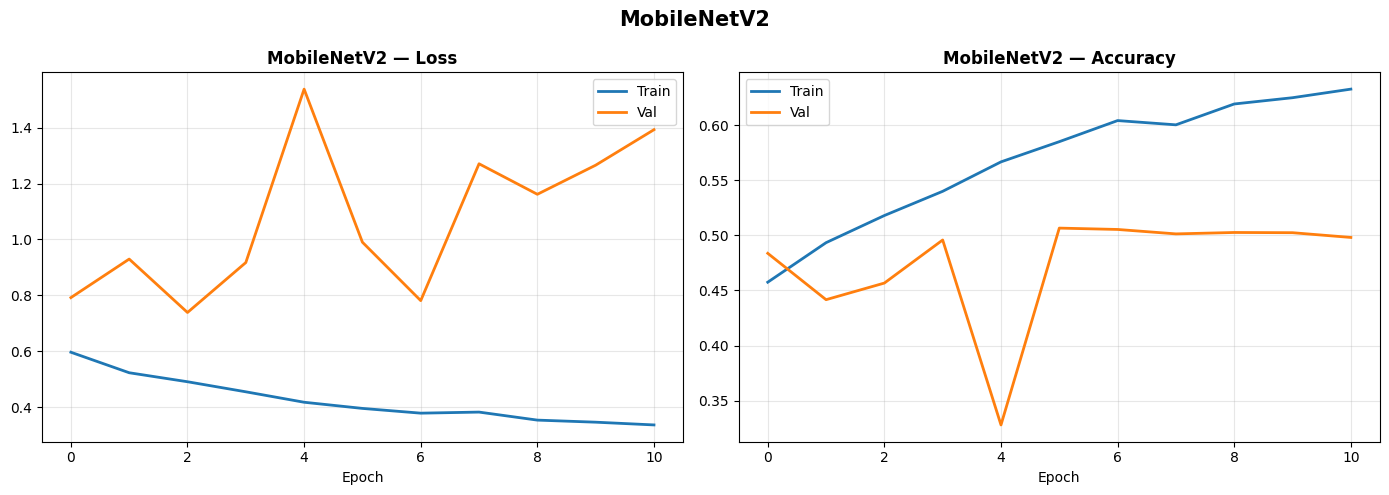


=== Evaluating MobileNetV2 ===


Inference:   0%|          | 0/1419 [00:00<?, ?it/s]

              precision    recall  f1-score   support

        pPB2     0.2807    0.4030    0.3309      1005
        pPNa     0.9745    0.5589    0.7104      5539
        pPNf     0.2528    0.6909    0.3702       906
          p2     0.7364    0.6999    0.7177      3759
          p3     0.1465    0.2620    0.1879       790
          p4     0.5212    0.4811    0.5004      3623
          p5     0.1825    0.2880    0.2234      1295
          p6     0.0793    0.1626    0.1066       953
          p7     0.1192    0.1731    0.1411      2213
          p8     0.4768    0.2674    0.3426      5101
         p9+     0.7509    0.3202    0.4490      7626
          pM     0.2911    0.4746    0.3609      2558
         pSB     0.4392    0.5643    0.4939      3500
          pB     0.2661    0.4148    0.3242      1497
         pEB     0.4274    0.4524    0.4395      5029

   micro avg     0.4328    0.4298    0.4313     45394
   macro avg     0.3963    0.4142    0.3799     45394
weighted avg     0.5341   

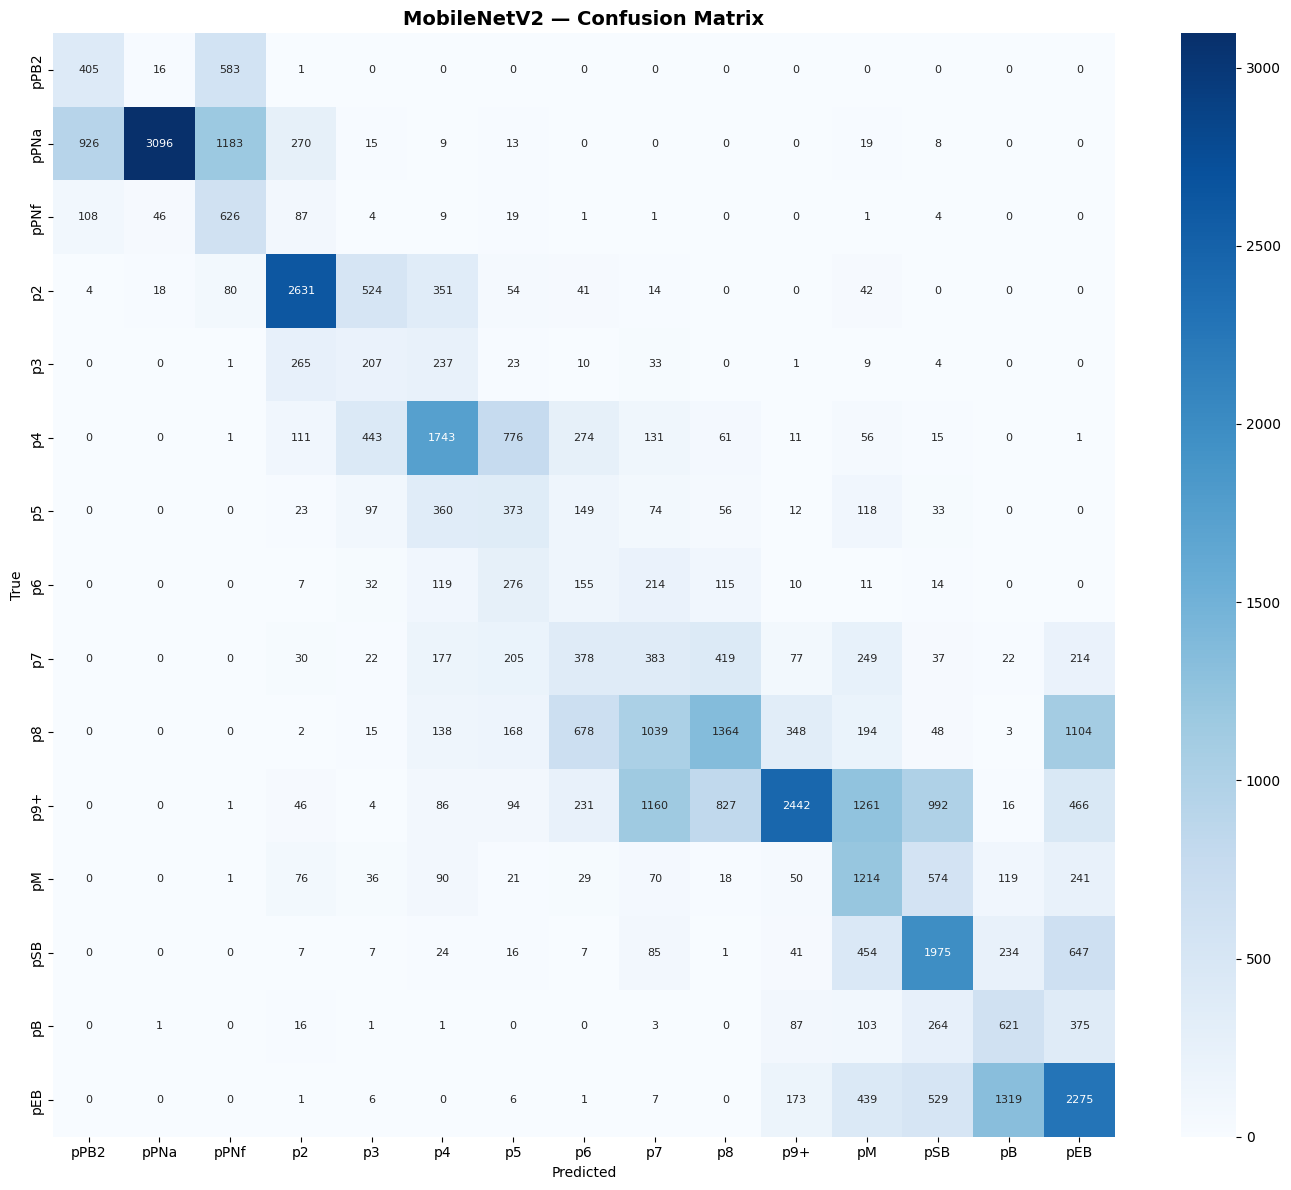

Macro ROC-AUC: 0.8893


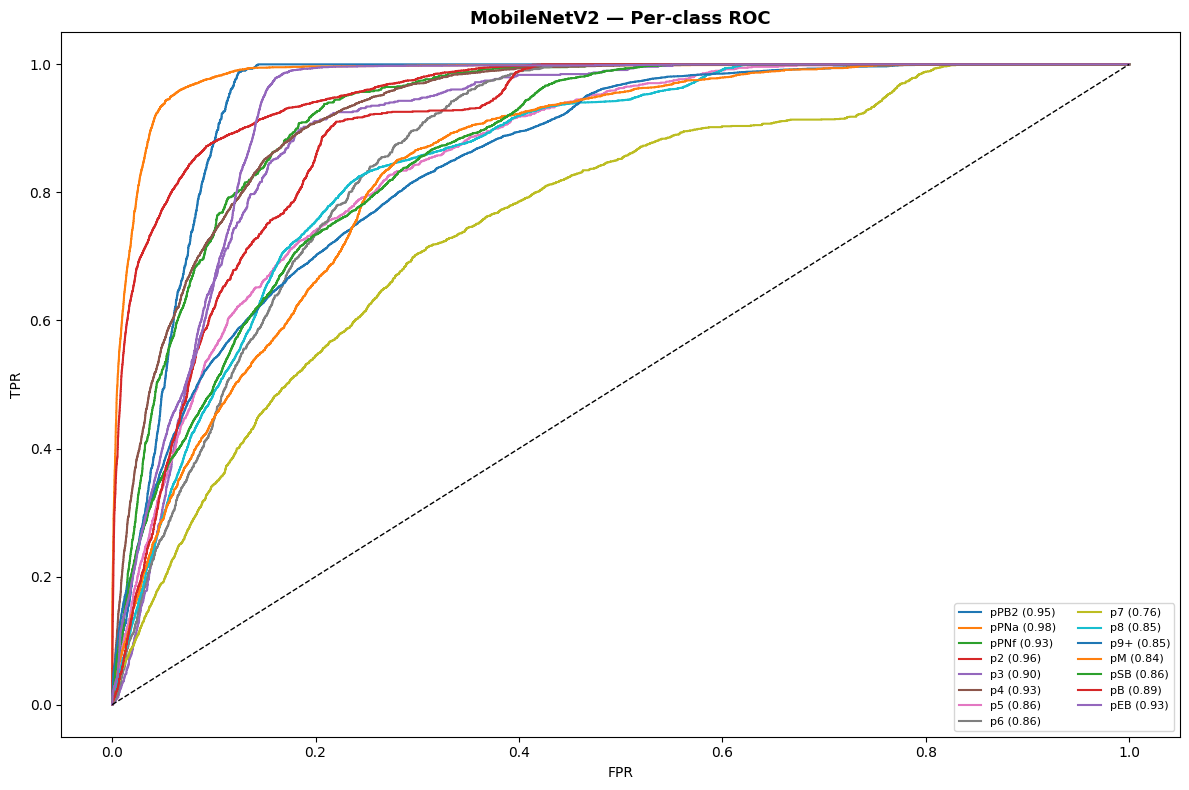


✅ MobileNetV2 Test Accuracy: 0.4298


In [10]:
clear_memory()
MODEL_NAME = 'MobileNetV2'
IMG_SIZE   = IMG_SIZE_MOBILE

train_ds = build_tf_dataset(train_df, IMG_SIZE, BATCH_SIZE, augment=True)
val_ds   = build_tf_dataset(val_df,   IMG_SIZE, BATCH_SIZE, shuffle=False)
test_ds  = build_tf_dataset(test_df,  IMG_SIZE, BATCH_SIZE, shuffle=False)


def build_mobilenet(img_size, num_classes):
    inputs = keras.Input(shape=(*img_size, 3), name='input')
    # KEY FIX: preprocess_input receives [0,255] float32 — correct for MobileNetV2
    # MobileNetV2 preprocess maps [0,255] → [-1, 1]
    x = layers.Lambda(
        tf.keras.applications.mobilenet_v2.preprocess_input,
        name='preprocess'
    )(inputs)
    base = MobileNetV2(include_top=False, weights='imagenet',
                       input_shape=(*img_size, 3), name='mobilenetv2')
    base.trainable = False
    x = base(x, training=False)
    outputs = build_head(x, num_classes)
    return Model(inputs, outputs, name='MobileNetV2')


model_mobile = build_mobilenet(IMG_SIZE, NUM_CLASSES)
model_mobile.summary(line_length=100)

# Fine-tune from block_13 (the last 3 inverted-residual blocks)
model_mobile = train_two_phase(
    model_mobile,
    base_layer_name  = 'mobilenetv2',
    fine_tune_from   = 'block_13_expand',
    train_ds=train_ds, val_ds=val_ds,
    model_name=MODEL_NAME
)

plot_history(MODEL_NAME)
metrics_mobile = evaluate_model(model_mobile, test_ds, MODEL_NAME)
_metrics_mobile = metrics_mobile


---
## 🤖 Section 9 — Model 2: InceptionV3

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "InceptionV3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                               ┃ Output Shape                    ┃           Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)                         │ (None, 299, 299, 3)             │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ preprocess (Lambda)                        │ (None, 299, 299, 3)             │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ inception_v3 (Functional)                  │ (None, 8, 8, 2048)              │        21,802,784 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ global_average_pooling2d                   │ (None, 2048)                    │                 0 │
│ (GlobalAveragePooling2D)                   │                                 │                   │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ batch_normalization_94                     │ (None, 2048)                    │             8,192 │
│ (BatchNormalization)                       │                                 │                   │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dense (Dense)                              │ (None, 1024)                    │         2,098,176 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ batch_normalization_95                     │ (None, 1024)                    │             4,096 │
│ (BatchNormalization)                       │                                 │                   │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ activation_94 (Activation)                 │ (None, 1024)                    │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dropout (Dropout)                          │ (None, 1024)                    │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dense_1 (Dense)                            │ (None, 512)                     │           524,800 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ batch_normalization_96                     │ (None, 512)                     │             2,048 │
│ (BatchNormalization)                       │                                 │                   │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ activation_95 (Activation)                 │ (None, 512)                     │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dropout_1 (Dropout)                        │ (None, 512)                     │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ logits (Dense)                             │ (None, 16)                      │             8,208 │
└────────────────────────────────────────────┴─────────────────────────────────┴───────────────────┘

 Total params: 24,448,304 (93.26 MB)

 Trainable params: 2,638,352 (10.06 MB)

...

Epoch   6/25:   0%|                              | 0/6730 [00:00<?, ?batch/s]

Epoch   7/25:   0%|                              | 0/6730 [00:00<?, ?batch/s]

Epoch   8/25:   0%|                              | 0/6730 [00:00<?, ?batch/s]

Epoch   9/25:   0%|                              | 0/6730 [00:00<?, ?batch/s]


Epoch 9: ReduceLROnPlateau reducing learning rate to 8.999999636216671e-07.
Epoch 9: early stopping
Restoring model weights from the end of the best epoch: 1.


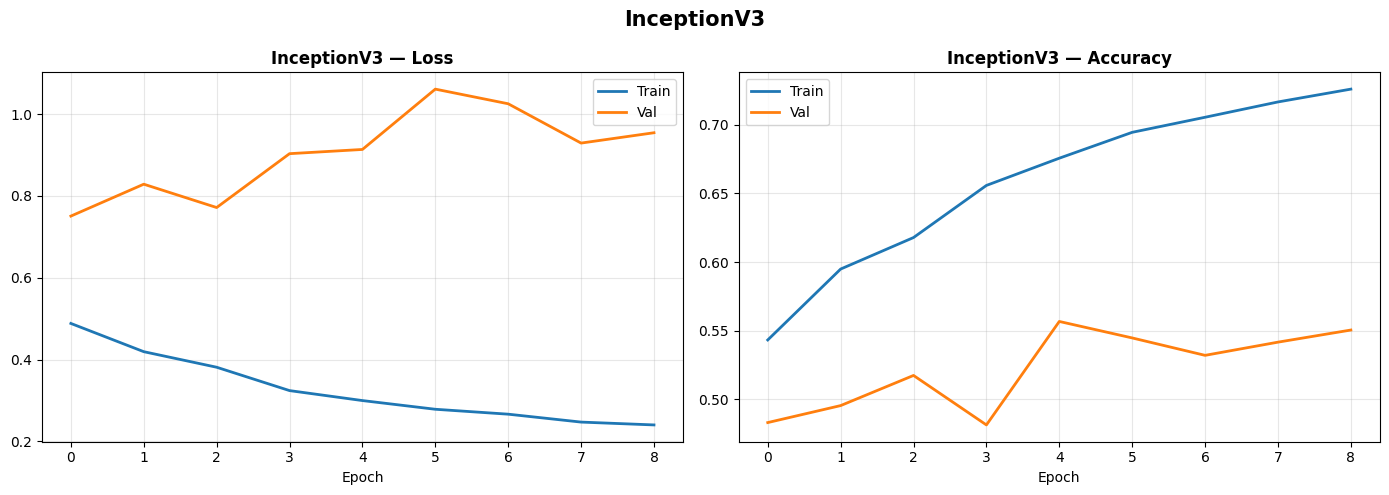


=== Evaluating InceptionV3 ===


Inference:   0%|          | 0/1419 [00:00<?, ?it/s]

              precision    recall  f1-score   support

        pPB2     0.3469    0.7801    0.4802      1005
        pPNa     0.9576    0.6765    0.7928      5539
        pPNf     0.3763    0.4702    0.4181       906
          p2     0.8005    0.7087    0.7518      3759
          p3     0.2344    0.3101    0.2670       790
          p4     0.5454    0.3663    0.4382      3623
          p5     0.1663    0.3097    0.2164      1295
          p6     0.0832    0.1228    0.0992       953
          p7     0.1544    0.0944    0.1172      2213
          p8     0.5933    0.4493    0.5114      5101
         p9+     0.5713    0.4428    0.4989      7626
          pM     0.2999    0.6157    0.4034      2558
         pSB     0.4073    0.5077    0.4520      3500
          pB     0.2133    0.3567    0.2670      1497
         pEB     0.6031    0.4204    0.4954      5029

   micro avg     0.4832    0.4756    0.4794     45394
   macro avg     0.4236    0.4421    0.4139     45394
weighted avg     0.5448   

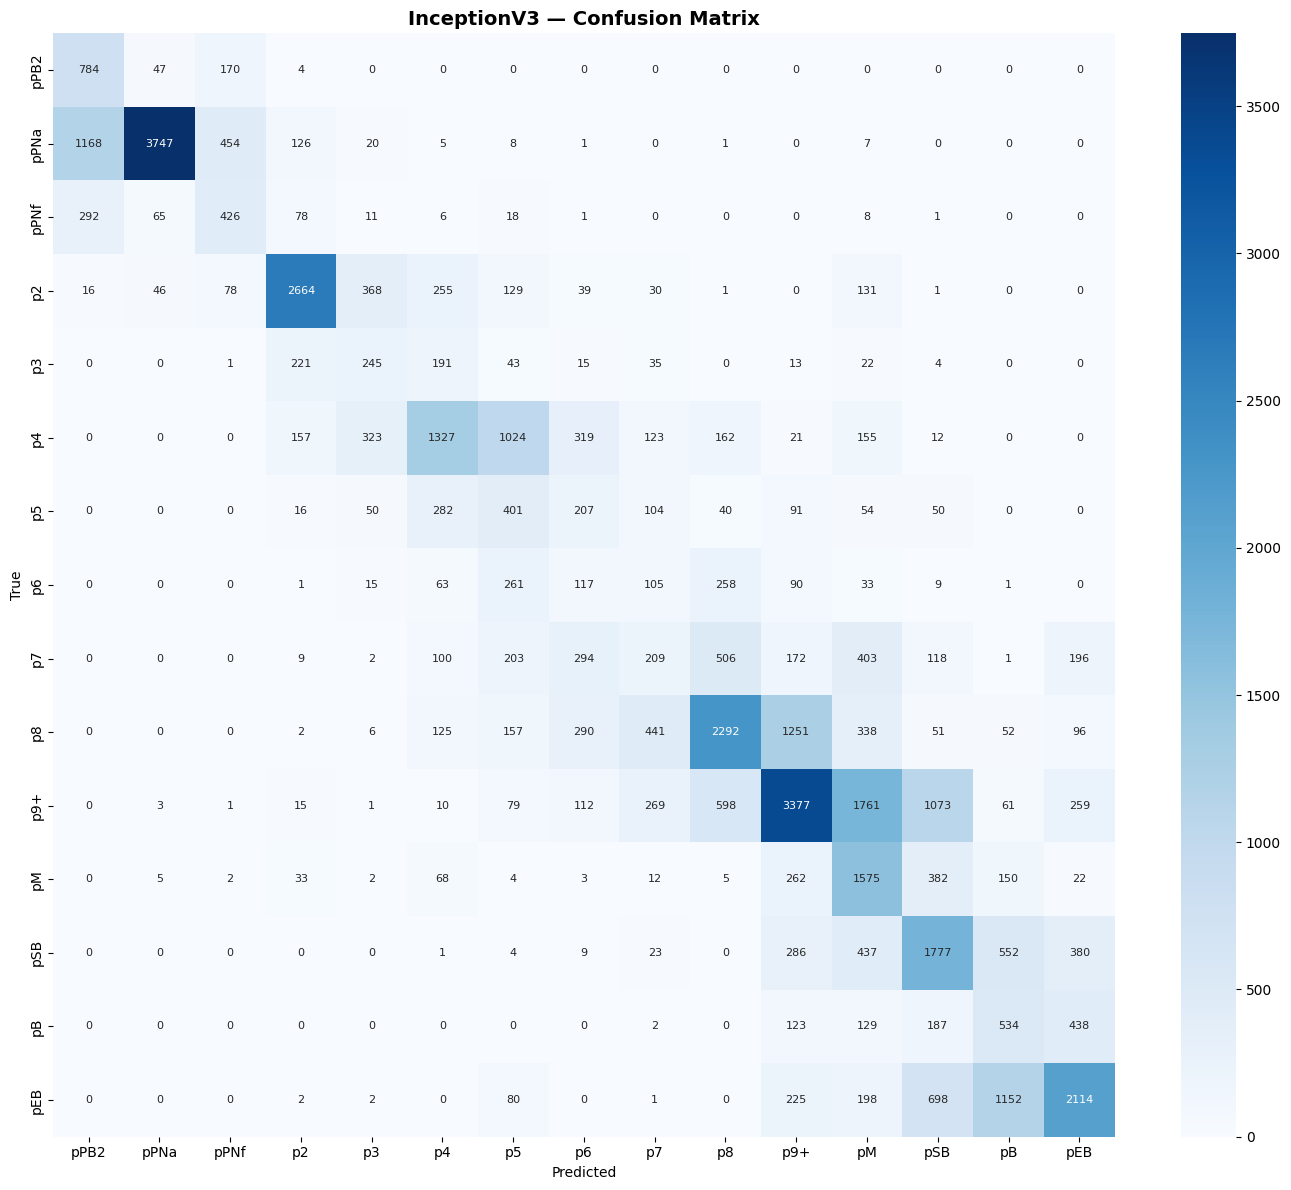

Macro ROC-AUC: 0.8941


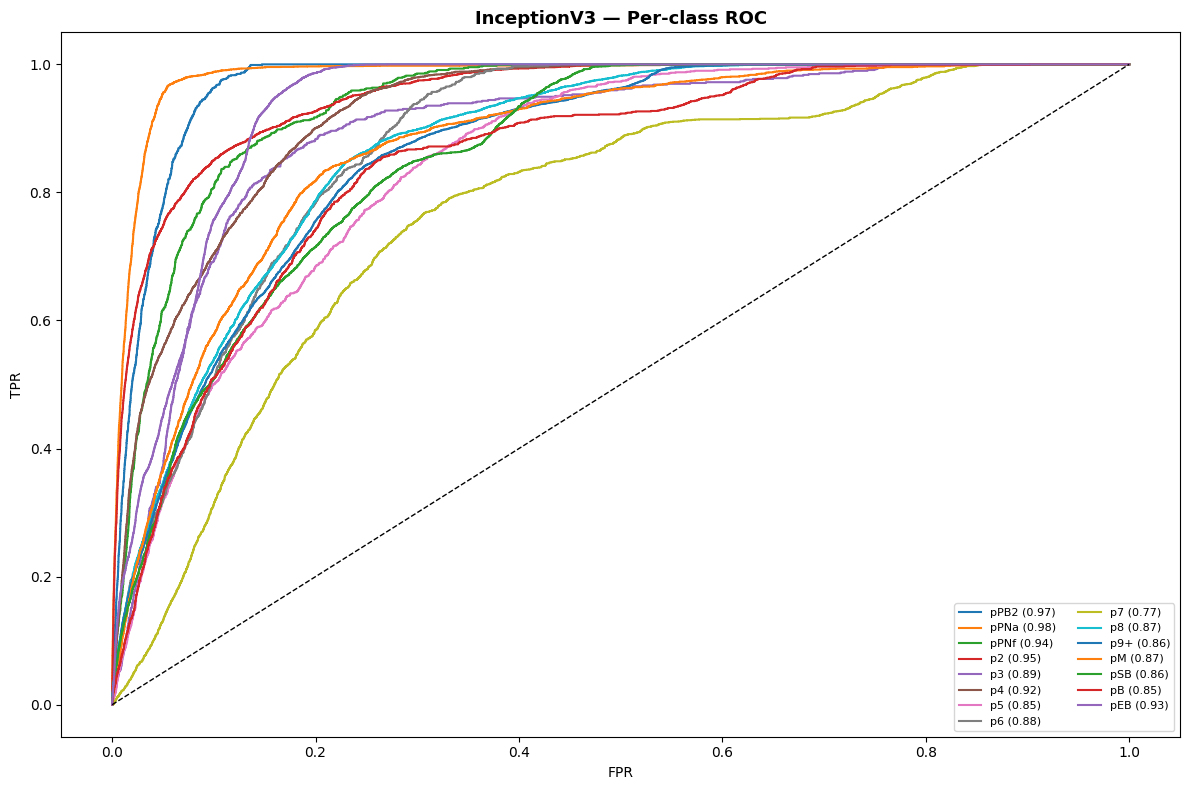


✅ InceptionV3 Test Accuracy: 0.4756


In [11]:
del model_mobile; clear_memory()
MODEL_NAME = 'InceptionV3'
IMG_SIZE   = IMG_SIZE_INCEPTION

train_ds = build_tf_dataset(train_df, IMG_SIZE, BATCH_SIZE, augment=True)
val_ds   = build_tf_dataset(val_df,   IMG_SIZE, BATCH_SIZE, shuffle=False)
test_ds  = build_tf_dataset(test_df,  IMG_SIZE, BATCH_SIZE, shuffle=False)


def build_inception(img_size, num_classes):
    inputs = keras.Input(shape=(*img_size, 3), name='input')
    # InceptionV3 preprocess maps [0,255] → [-1, 1]
    x = layers.Lambda(
        tf.keras.applications.inception_v3.preprocess_input,
        name='preprocess'
    )(inputs)
    base = InceptionV3(include_top=False, weights='imagenet',
                       input_shape=(*img_size, 3), name='inception_v3')
    base.trainable = False
    x = base(x, training=False)
    outputs = build_head(x, num_classes)
    return Model(inputs, outputs, name='InceptionV3')


model_inception = build_inception(IMG_SIZE, NUM_CLASSES)
model_inception.summary(line_length=100)

model_inception = train_two_phase(
    model_inception,
    base_layer_name='inception_v3',
    fine_tune_from='mixed7',
    train_ds=train_ds, val_ds=val_ds,
    model_name=MODEL_NAME
)

plot_history(MODEL_NAME)
metrics_inception = evaluate_model(model_inception, test_ds, MODEL_NAME)
_metrics_inception = metrics_inception


---
## 🤖 Section 10 — Model 3: VGG16


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "VGG16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                               ┃ Output Shape                    ┃           Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)                         │ (None, 224, 224, 3)             │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ preprocess (Lambda)                        │ (None, 224, 224, 3)             │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ vgg16 (Functional)                         │ (None, 7, 7, 512)               │        14,714,688 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ global_average_pooling2d                   │ (None, 512)                     │                 0 │
│ (GlobalAveragePooling2D)                   │                                 │                   │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ batch_normalization (BatchNormalization)   │ (None, 512)                     │             2,048 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dense (Dense)                              │ (None, 2048)                    │         1,050,624 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ batch_normalization_1 (BatchNormalization) │ (None, 2048)                    │             8,192 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ activation (Activation)                    │ (None, 2048)                    │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dropout (Dropout)                          │ (None, 2048)                    │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dense_1 (Dense)                            │ (None, 1024)                    │         2,098,176 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ batch_normalization_2 (BatchNormalization) │ (None, 1024)                    │             4,096 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ activation_1 (Activation)                  │ (None, 1024)                    │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dropout_1 (Dropout)                        │ (None, 1024)                    │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ logits (Dense)                             │ (None, 16)                      │            16,400 │
└────────────────────────────────────────────┴─────────────────────────────────┴───────────────────┘

 Total params: 17,894,224 (68.26 MB)

 Trainable params: 3,172,368 (12.10 MB)

...

Epoch   6/25:   0%|                              | 0/6730 [00:00<?, ?batch/s]

Epoch   7/25:   0%|                              | 0/6730 [00:00<?, ?batch/s]

Epoch   8/25:   0%|                              | 0/6730 [00:00<?, ?batch/s]

Epoch   9/25:   0%|                              | 0/6730 [00:00<?, ?batch/s]


Epoch 9: ReduceLROnPlateau reducing learning rate to 8.999999636216671e-07.
Epoch 9: early stopping
Restoring model weights from the end of the best epoch: 1.


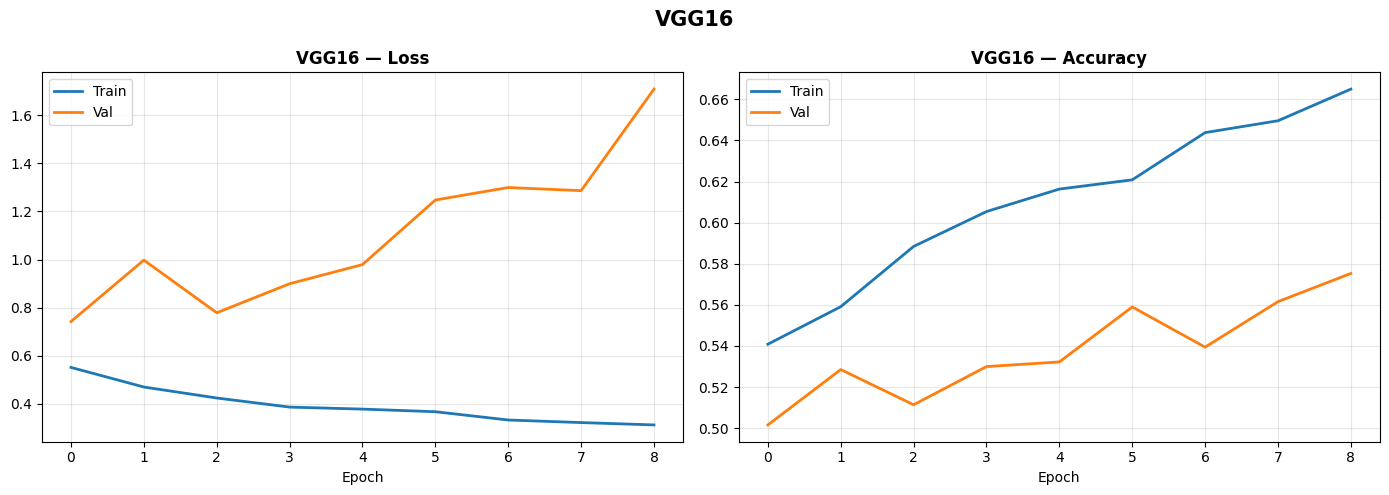


=== Evaluating VGG16 ===


Inference:   0%|          | 0/1419 [00:00<?, ?it/s]

              precision    recall  f1-score   support

        pPB2     0.3537    0.6965    0.4692      1005
        pPNa     0.9557    0.6702    0.7879      5539
        pPNf     0.3441    0.5784    0.4315       906
          p2     0.7627    0.7534    0.7580      3759
          p3     0.1543    0.1316    0.1421       790
          p4     0.5399    0.5117    0.5254      3623
          p5     0.2565    0.2965    0.2751      1295
          p6     0.1039    0.1480    0.1221       953
          p7     0.1346    0.1075    0.1196      2213
          p8     0.4932    0.3484    0.4083      5101
         p9+     0.6522    0.4028    0.4981      7626
          pM     0.2512    0.5332    0.3416      2558
         pSB     0.3426    0.5266    0.4151      3500
          pB     0.2538    0.2999    0.2750      1497
         pEB     0.6038    0.5236    0.5608      5029

   micro avg     0.4797    0.4764    0.4781     45394
   macro avg     0.4135    0.4352    0.4086     45394
weighted avg     0.5371   

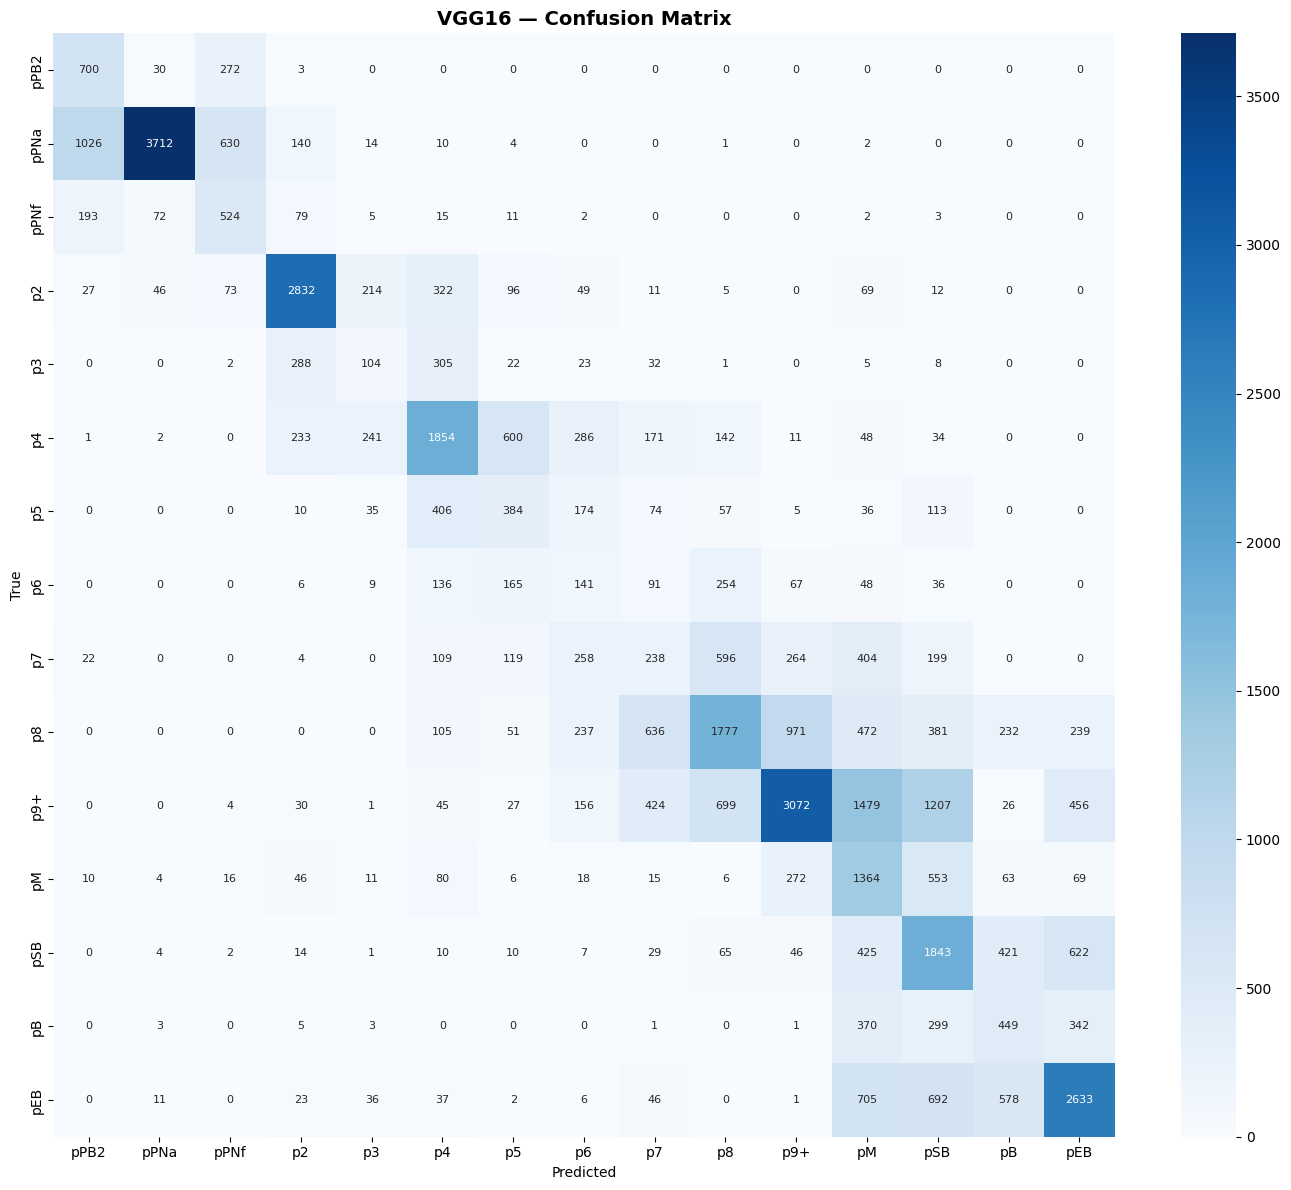

Macro ROC-AUC: 0.8425


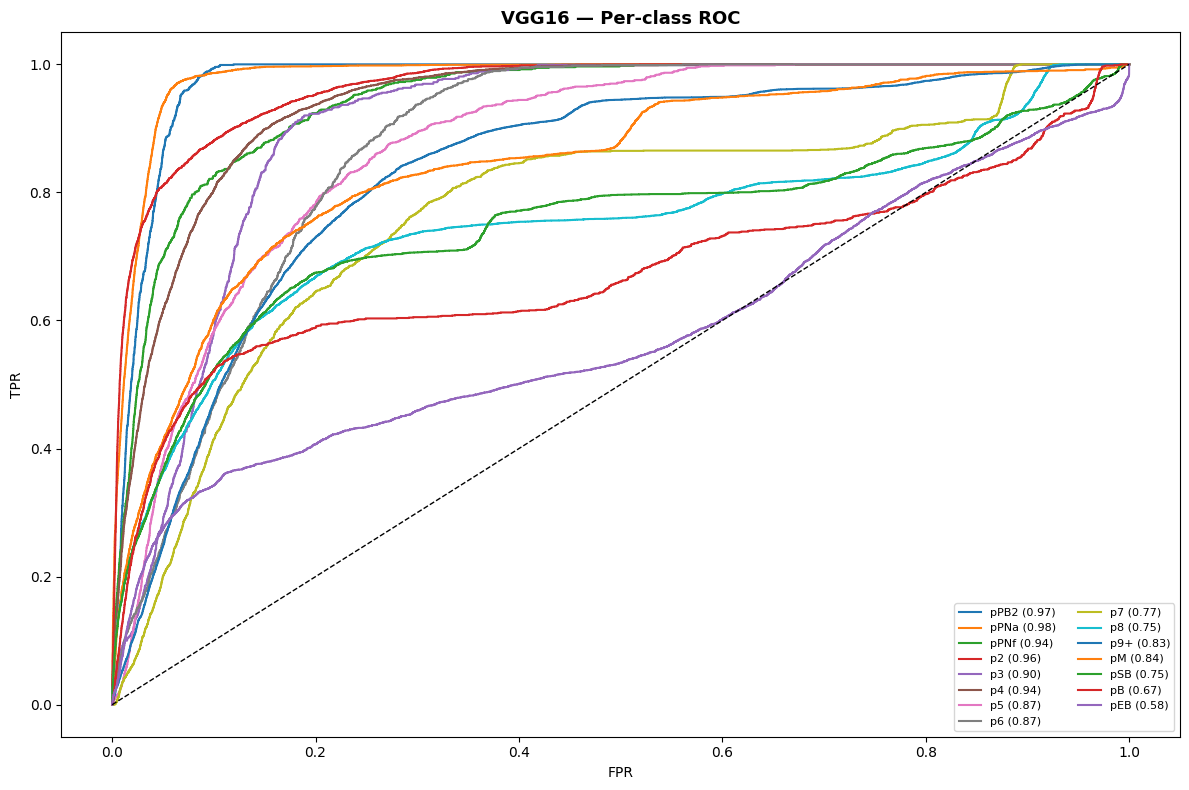


✅ VGG16 Test Accuracy: 0.4764


In [12]:
del model_inception; clear_memory()
MODEL_NAME = 'VGG16'
IMG_SIZE   = IMG_SIZE_VGG

train_ds = build_tf_dataset(train_df, IMG_SIZE, BATCH_SIZE, augment=True)
val_ds   = build_tf_dataset(val_df,   IMG_SIZE, BATCH_SIZE, shuffle=False)
test_ds  = build_tf_dataset(test_df,  IMG_SIZE, BATCH_SIZE, shuffle=False)


def build_vgg16(img_size, num_classes):
    inputs = keras.Input(shape=(*img_size, 3), name='input')
    # VGG preprocess: mean subtraction in BGR, [0,255] input
    x = layers.Lambda(
        tf.keras.applications.vgg16.preprocess_input,
        name='preprocess'
    )(inputs)
    base = VGG16(include_top=False, weights='imagenet',
                 input_shape=(*img_size, 3), name='vgg16')
    base.trainable = False
    x = base(x, training=False)
    outputs = build_head(x, num_classes, dense1=2048, dense2=1024)
    return Model(inputs, outputs, name='VGG16')


model_vgg16 = build_vgg16(IMG_SIZE, NUM_CLASSES)
model_vgg16.summary(line_length=100)

# VGG has no BN layers in base — only our head has BN
# Fine-tune from block5_conv1 (last 3 conv layers)
model_vgg16 = train_two_phase(
    model_vgg16,
    base_layer_name='vgg16',
    fine_tune_from='block5_conv1',
    train_ds=train_ds, val_ds=val_ds,
    model_name=MODEL_NAME
)

plot_history(MODEL_NAME)
metrics_vgg16 = evaluate_model(model_vgg16, test_ds, MODEL_NAME)
_metrics_vgg16 = metrics_vgg16


Due to the GPU limit Reached i have done the vgg19 in another file.